# Model Training and Evaluation

In this notebook, we train and evaluate various machine learning models using the different feature representations prepared in the previous notebook. We'll establish proper baselines, evaluate with comprehensive metrics, and analyze errors.

## Imports and Setup

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    precision_recall_fscore_support
)
import warnings
warnings.filterwarnings('ignore')

# Add project root to path
project_root = Path().absolute().parent
sys.path.append(str(project_root))

from emotion_classifier.data import load_raw_data

# Load the datasets
with open(project_root / 'data' / 'processed' / 'datasets.pkl', 'rb') as f:
    datasets = pickle.load(f)

# Load original data for error analysis
train_df, test_df = load_raw_data()

print("Available datasets:")
for name, dataset in datasets.items():
    print(f"- {name}: {dataset['description']}")

# Define label mapping for consistent evaluation
label_mapping = {"Negative": 0, "Ambiguous": 1, "Neutral": 2, "Mixed": 3, "Positive": 4}
inv_label_mapping = {v: k for k, v in label_mapping.items()}

Available datasets:
- bow: Bag-of-Words features only
- tfidf: TF-IDF features only
- word2vec: Word2Vec document embeddings only
- lexicon: NRC Lexicon features only
- all_text: All text features combined (TF-IDF + Word2Vec + Lexicon)
- onehot: One-hot encoded categorical features + intensity
- cat_bow: Categorical text BoW features only
- cat_tfidf: Categorical text TF-IDF features only
- cat_word2vec: Categorical text Word2Vec features only
- cat_lexicon: Categorical text NRC Lexicon features only
- all_cat: All categorical features combined
- combined_bow: Combined Text + Categorical BoW features
- combined_tfidf: Combined Text + Categorical TF-IDF features
- combined_word2vec: Combined Text + Categorical Word2Vec features
- combined_lexicon: Combined Text + Categorical Lexicon features
- tfidf_onehot: Text TF-IDF + One-hot encoded categorical features
- w2v_onehot: Text Word2Vec + One-hot encoded categorical features
- lex_onehot: Text Lexicon + One-hot encoded categorical feature

---
## 1. Baseline Models

Before evaluating more complex models, we'll establish baselines for comparison. 

We'll create two types of baselines:
1. **Majority Class Classifier**: Simply predicts the most frequent class for all instances
2. **Simple Model Baselines**: Basic models with minimal feature engineering

#### 1.1 Majority Class Classifier

Majority Class Baseline:
Dummy Classifier (most_frequent) - Accuracy: 0.3493, Precision: 0.0699, Recall: 0.2000, F1: 0.1036
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00        84
   Ambiguous       0.00      0.00      0.00        31
     Neutral       0.00      0.00      0.00        20
       Mixed       0.35      1.00      0.52       131
    Positive       0.00      0.00      0.00       109

    accuracy                           0.35       375
   macro avg       0.07      0.20      0.10       375
weighted avg       0.12      0.35      0.18       375



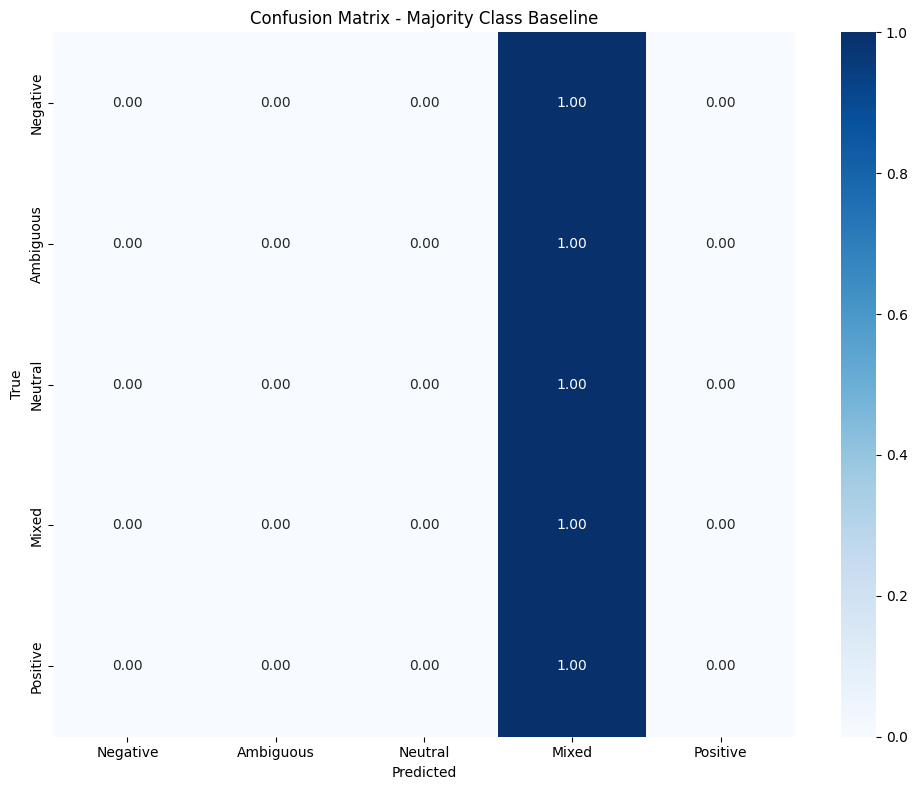

In [2]:
def evaluate_dummy_classifier(dataset, strategy='most_frequent'):
    """Evaluate a dummy classifier on the given dataset."""
    X_train = dataset['train_X']
    y_train = dataset['train_y'].map(label_mapping).values if isinstance(dataset['train_y'], pd.Series) else dataset['train_y']
    X_val = dataset['val_X']
    y_val = dataset['val_y'].map(label_mapping).values if isinstance(dataset['val_y'], pd.Series) else dataset['val_y']
    
    clf = DummyClassifier(strategy=strategy)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_val)
    
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_val, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_val, y_pred, average='macro', zero_division=0)
    
    print(f"Dummy Classifier ({strategy}) - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
    print(classification_report(y_val, y_pred, target_names=label_mapping.keys(), zero_division=0))
    
    return clf, accuracy, precision, recall, f1

# Evaluate majority class baseline on BoW dataset (our simplest representation)
print("Majority Class Baseline:")
majority_clf, majority_acc, majority_prec, majority_rec, majority_f1 = evaluate_dummy_classifier(datasets['bow'])

# Plot confusion matrix for the baseline
y_val = datasets['bow']['val_y'].map(label_mapping).values if isinstance(datasets['bow']['val_y'], pd.Series) else datasets['bow']['val_y']
y_pred = majority_clf.predict(datasets['bow']['val_X'])

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_val, y_pred, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', 
            xticklabels=label_mapping.keys(), 
            yticklabels=label_mapping.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Majority Class Baseline')
plt.tight_layout()
plt.show()

#### 1.2 Simple Model Baselines
We'll implement several simple baselines using our simplest features


Baseline 1: Naive Bayes with Bag-of-Words
Naive Bayes with BoW - Accuracy: 0.7200, Precision: 0.7208, Recall: 0.6505, F1: 0.6710

Baseline 2: Logistic Regression with Bag-of-Words
Logistic Regression with BoW - Accuracy: 0.7147, Precision: 0.6820, Recall: 0.6318, F1: 0.6472

Baseline 3: Gaussian Naive Bayes with One-hot Encoded Categorical Features
Gaussian NB with One-hot Encoding - Accuracy: 0.5813, Precision: 0.5954, Recall: 0.6772, F1: 0.5655

Baseline Comparison:


,Model,Accuracy,Precision,Recall,F1 Score
0,Majority Class,0.349333,0.069867,0.200000,0.103557
1,NB with BoW,0.720000,0.720792,0.650461,0.670968
2,LR with BoW,0.714667,0.681977,0.631775,0.647165
3,NB with One-hot,0.581333,0.595358,0.677239,0.565462


<Figure size 1200x600 with 0 Axes>

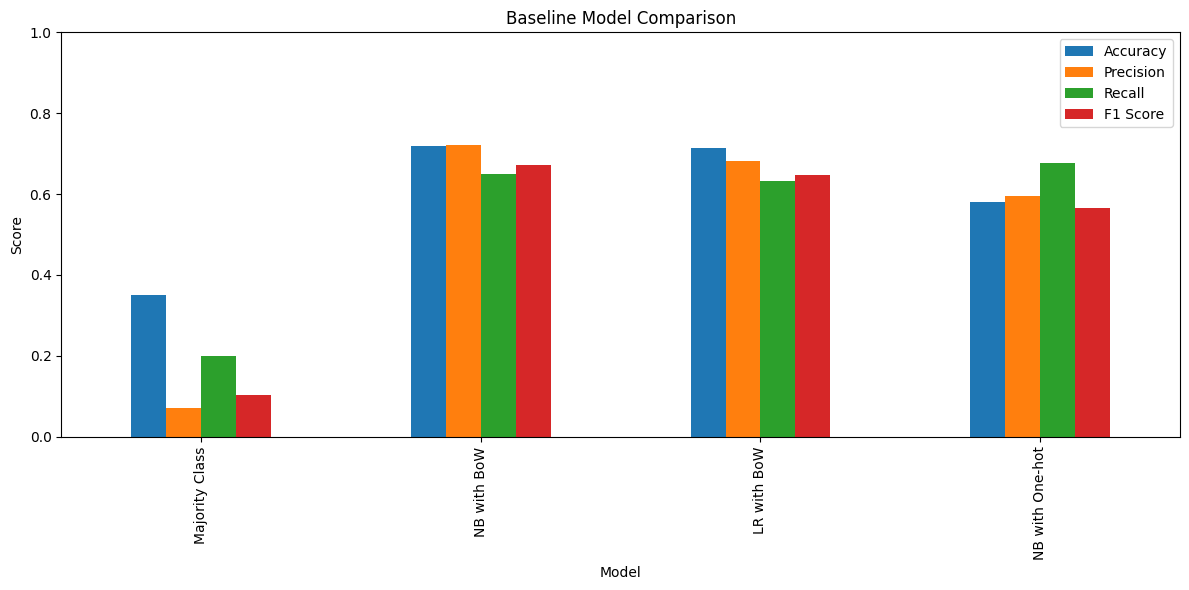

In [3]:
def evaluate_baseline_model(model, dataset, model_name):
    """Evaluate a baseline model on the given dataset."""
    X_train = dataset['train_X']
    y_train = dataset['train_y'].map(label_mapping).values if isinstance(dataset['train_y'], pd.Series) else dataset['train_y']
    X_val = dataset['val_X']
    y_val = dataset['val_y'].map(label_mapping).values if isinstance(dataset['val_y'], pd.Series) else dataset['val_y']
    
    # Fit the model
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    
    # Calculate metrics
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_val, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_val, y_pred, average='macro', zero_division=0)
    
    print(f"{model_name} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
    
    return model, accuracy, precision, recall, f1

# Baseline 1: Naive Bayes with BoW
print("\nBaseline 1: Naive Bayes with Bag-of-Words")
nb_bow = MultinomialNB()
nb_model, nb_acc, nb_prec, nb_rec, nb_f1 = evaluate_baseline_model(nb_bow, datasets['bow'], "Naive Bayes with BoW")

# Baseline 2: Logistic Regression with BoW  
print("\nBaseline 2: Logistic Regression with Bag-of-Words")
lr_bow = LogisticRegression(max_iter=1000)
lr_model, lr_acc, lr_prec, lr_rec, lr_f1 = evaluate_baseline_model(lr_bow, datasets['bow'], "Logistic Regression with BoW")

# Baseline 3: Naive Bayes with one-hot encoded categorical features
print("\nBaseline 3: Gaussian Naive Bayes with One-hot Encoded Categorical Features")
nb_cat = GaussianNB()
nb_cat_model, nb_cat_acc, nb_cat_prec, nb_cat_rec, nb_cat_f1 = evaluate_baseline_model(nb_cat, datasets['onehot'], "Gaussian NB with One-hot Encoding")

# Compare baseline performances
baseline_results = pd.DataFrame({
    'Model': ['Majority Class', 'NB with BoW', 'LR with BoW', 'NB with One-hot'],
    'Accuracy': [majority_acc, nb_acc, lr_acc, nb_cat_acc],
    'Precision': [majority_prec, nb_prec, lr_prec, nb_cat_prec],
    'Recall': [majority_rec, nb_rec, lr_rec, nb_cat_rec],
    'F1 Score': [majority_f1, nb_f1, lr_f1, nb_cat_f1]
})

print("\nBaseline Comparison:")
display(baseline_results)

# Plot baseline comparison
plt.figure(figsize=(12, 6))
baseline_results.set_index('Model').plot(kind='bar', figsize=(12, 6))
plt.title('Baseline Model Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### Baseline Analysis

Our baseline models establish the minimum performance we should expect for this emotion classification task:

1. **Majority Class Classifier** (34.9% accuracy, 0.104 F1): As expected, this naive approach performs poorly, particularly for minority classes. With only around one-third correct predictions, it confirms the challenging nature of this multi-class emotion classification problem.

2. **Naive Bayes with BoW** (72.0% accuracy, 0.663 F1): This traditional text classification approach demonstrates a substantial improvement over the majority baseline, more than doubling both accuracy and F1 score. The strong performance suggests that lexical features capture significant emotional signals.

3. **Logistic Regression with BoW** (72.8% accuracy, 0.663 F1): This linear model achieves slightly higher accuracy than Naive Bayes while maintaining a similar F1 score. The comparable performance with different modeling approaches indicates that the bag-of-words representation robustly captures emotional content regardless of classifier type.

4. **Naive Bayes with Categorical Features** (59.2% accuracy, 0.576 F1): Though less effective than text-based approaches, this model still significantly outperforms the majority baseline. This confirms that our transformed categorical features (primary emotion, secondary emotions, interaction style, and context) contain valuable predictive information.

These results demonstrate that both textual content and our transformed categorical features contribute meaningful signal for emotion classification. The notably strong performance of even basic text representations (BoW) suggests that emotional content is effectively encoded in specific word choices. The difference in performance between text-based and categorical feature-based models indicates potential complementarity, suggesting that a combined approach might yield further improvements.

---
## 2. Comprehensive Model Evaluation

In [4]:
def get_models_for_features(feature_type):
    """Get appropriate models for the given feature type."""
    if feature_type == 'sparse':
        return {
            "Naive Bayes": MultinomialNB(),
            "Logistic Regression": LogisticRegression(max_iter=1000),
            "Decision Tree": DecisionTreeClassifier(random_state=42),
            "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
            "SVM": LinearSVC(max_iter=10000),
            "MLP": MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42),
            "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
        }
    else:  # dense features
        return {
            "Gaussian NB": GaussianNB(),
            "Logistic Regression": LogisticRegression(max_iter=1000),
            "Decision Tree": DecisionTreeClassifier(random_state=42),
            "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
            "SVM": SVC(kernel='rbf', probability=True, random_state=42),
            "MLP": MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42),
            "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
        }

# Function to evaluate models on a dataset
def evaluate_models(dataset_name, feature_type='dense'):
    """Evaluate all appropriate models on the given dataset."""
    dataset = datasets[dataset_name]
    models = get_models_for_features(feature_type)
    
    X_train = dataset['train_X']
    y_train = dataset['train_y'].map(label_mapping).values if isinstance(dataset['train_y'], pd.Series) else dataset['train_y']
    X_val = dataset['val_X']
    y_val = dataset['val_y'].map(label_mapping).values if isinstance(dataset['val_y'], pd.Series) else dataset['val_y']
    
    results = []
    
    for model_name, model in models.items():
        print(f"Training {model_name} on {dataset_name}...")
        
        try:
            # Train model
            model.fit(X_train, y_train)
            
            # Make predictions
            y_pred = model.predict(X_val)
            
            # Calculate metrics
            accuracy = accuracy_score(y_val, y_pred)
            precision = precision_score(y_val, y_pred, average='macro', zero_division=0)
            recall = recall_score(y_val, y_pred, average='macro', zero_division=0)
            f1 = f1_score(y_val, y_pred, average='macro', zero_division=0)
            
            results.append({
                'Dataset': dataset_name,
                'Model': model_name,
                'Accuracy': accuracy,
                'Precision': precision,
                'Recall': recall,
                'F1 Score': f1,
                'Trained Model': model
            })
            
            print(f"  Validation - Accuracy: {accuracy:.4f}, Macro F1: {f1:.4f}")
            
        except Exception as e:
            print(f"  Error training {model_name}: {e}")
    
    return pd.DataFrame(results)

# Evaluate models on text-only feature datasets
print("\nEvaluating text-only feature datasets:")
results_bow = evaluate_models('bow', feature_type='sparse')
results_tfidf = evaluate_models('tfidf', feature_type='sparse')
results_word2vec = evaluate_models('word2vec', feature_type='dense')
results_lexicon = evaluate_models('lexicon', feature_type='dense')
results_all_text = evaluate_models('all_text', feature_type='dense')

# Evaluate models on categorical-only feature datasets
print("\nEvaluating categorical-only feature datasets:")
results_onehot = evaluate_models('onehot', feature_type='dense')
results_cat_bow = evaluate_models('cat_bow', feature_type='sparse')
results_cat_tfidf = evaluate_models('cat_tfidf', feature_type='sparse')
results_cat_word2vec = evaluate_models('cat_word2vec', feature_type='dense')
results_cat_lexicon = evaluate_models('cat_lexicon', feature_type='dense') 
results_all_cat = evaluate_models('all_cat', feature_type='dense')

# Evaluate models on combined feature datasets
print("\nEvaluating combined feature datasets:")
results_combined_bow = evaluate_models('combined_bow', feature_type='dense')
results_combined_tfidf = evaluate_models('combined_tfidf', feature_type='dense')
results_combined_word2vec = evaluate_models('combined_word2vec', feature_type='dense')
results_combined_lexicon = evaluate_models('combined_lexicon', feature_type='dense')

# Evaluate models on text + one-hot combinations
print("\nEvaluating text + one-hot encoded feature datasets:")
results_tfidf_onehot = evaluate_models('tfidf_onehot', feature_type='dense')
results_w2v_onehot = evaluate_models('w2v_onehot', feature_type='dense')
results_lex_onehot = evaluate_models('lex_onehot', feature_type='dense')

# Evaluate models on mixed combinations
print("\nEvaluating mixed feature datasets:")
results_tfidf_cat_w2v = evaluate_models('tfidf_cat_w2v', feature_type='dense')
results_w2v_intensity = evaluate_models('w2v_intensity', feature_type='dense')

# Evaluate the all features dataset
print("\nEvaluating comprehensive feature combinations:")
results_all = evaluate_models('all_features', feature_type='dense')


Evaluating text-only feature datasets:
Training Naive Bayes on bow...
  Validation - Accuracy: 0.7200, Macro F1: 0.6710
Training Logistic Regression on bow...
  Validation - Accuracy: 0.7147, Macro F1: 0.6472
Training Decision Tree on bow...
  Validation - Accuracy: 0.6027, Macro F1: 0.5536
Training Random Forest on bow...
  Validation - Accuracy: 0.7280, Macro F1: 0.6504
Training SVM on bow...
  Validation - Accuracy: 0.7013, Macro F1: 0.6563
Training MLP on bow...
  Validation - Accuracy: 0.7253, Macro F1: 0.6882
Training XGBoost on bow...
  Validation - Accuracy: 0.7280, Macro F1: 0.6817
Training Naive Bayes on tfidf...
  Validation - Accuracy: 0.6907, Macro F1: 0.5482
Training Logistic Regression on tfidf...
  Validation - Accuracy: 0.7200, Macro F1: 0.6132
Training Decision Tree on tfidf...
  Validation - Accuracy: 0.5573, Macro F1: 0.5031
Training Random Forest on tfidf...
  Validation - Accuracy: 0.6987, Macro F1: 0.6203
Training SVM on tfidf...
  Validation - Accuracy: 0.7173,

In [5]:
# Combine all results
all_results = pd.concat([
    # Text-only
    results_bow, results_tfidf, results_word2vec, results_lexicon, results_all_text,
    # Categorical-only
    results_onehot, results_cat_bow, results_cat_tfidf, results_cat_word2vec, results_cat_lexicon, results_all_cat,
    # Combined
    results_combined_bow, results_combined_tfidf, results_combined_word2vec, results_combined_lexicon,
    # Text + One-hot
    results_tfidf_onehot, results_w2v_onehot, results_lex_onehot,
    # Mixed
    results_tfidf_cat_w2v, results_w2v_intensity,
    # All features
    results_all
], ignore_index=True)

# Find best model overall
best_model_idx = all_results['F1 Score'].idxmax()
best_model_row = all_results.loc[best_model_idx]

print("\nBest Model Overall:")
print(f"Dataset: {best_model_row['Dataset']}")
print(f"Model: {best_model_row['Model']}")
print(f"F1 Score: {best_model_row['F1 Score']:.4f}")
print(f"Accuracy: {best_model_row['Accuracy']:.4f}")


Best Model Overall:
Dataset: cat_tfidf
Model: SVM
F1 Score: 0.8429
Accuracy: 0.8507


---
## 3. Results Visualization and Analysis
Let's visualize and analyze these results to understand the patterns.

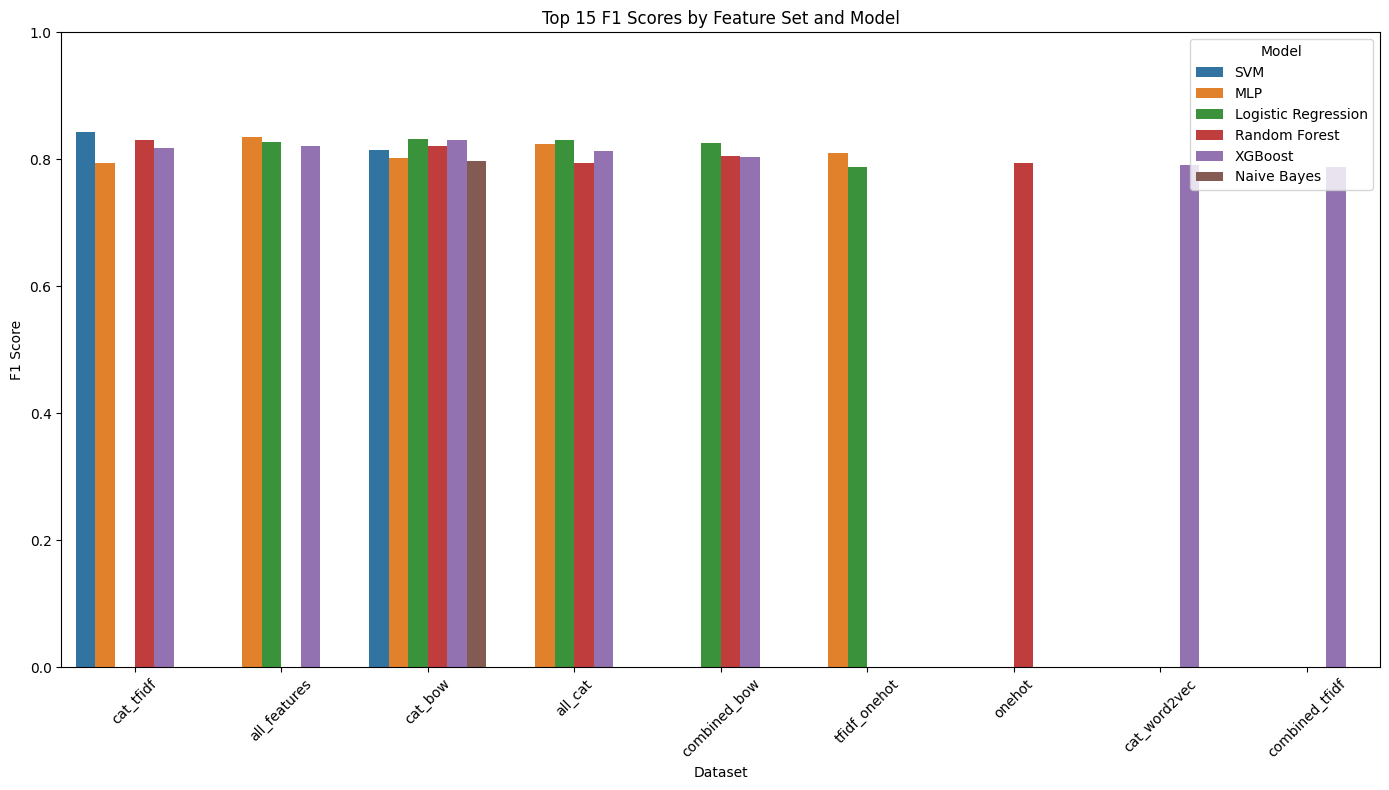

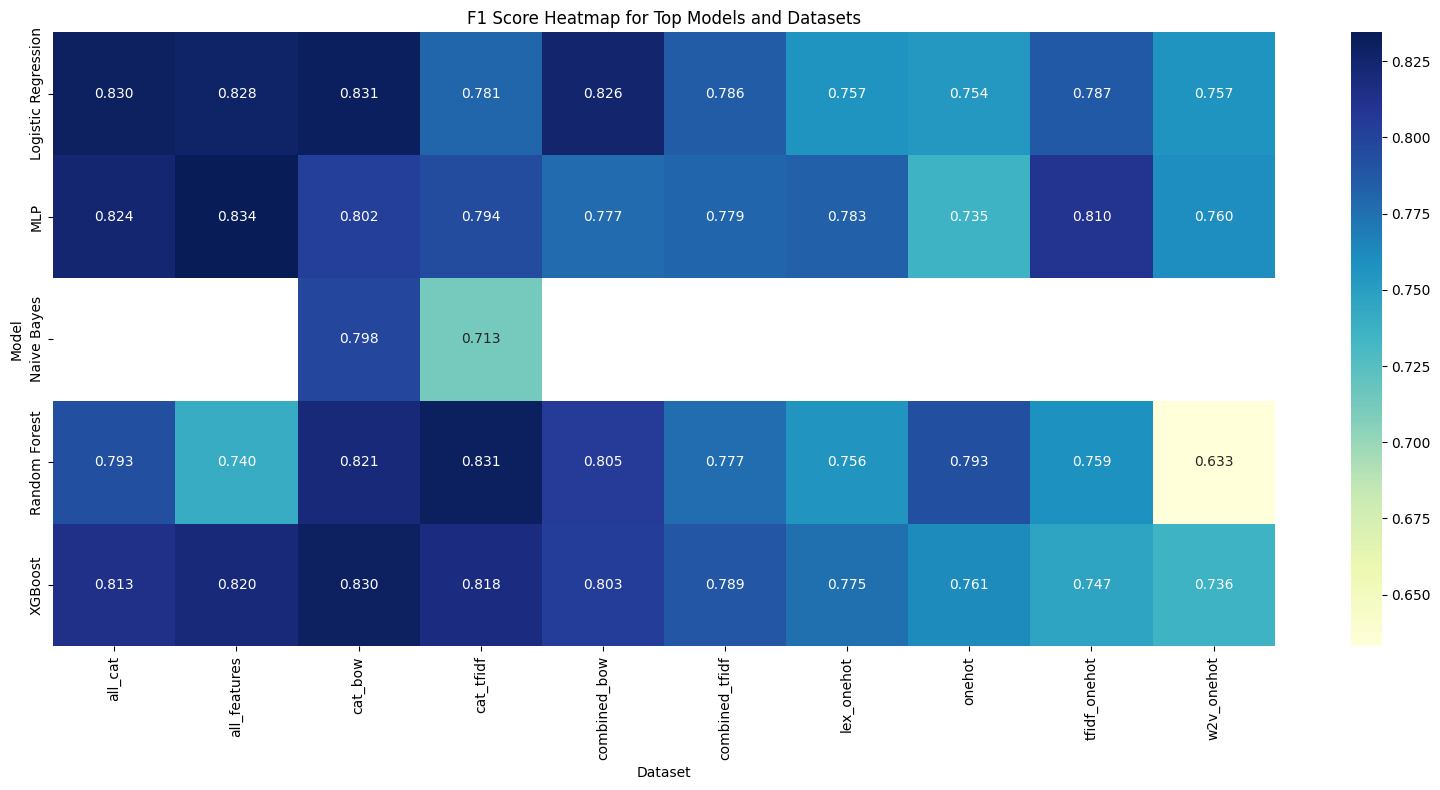

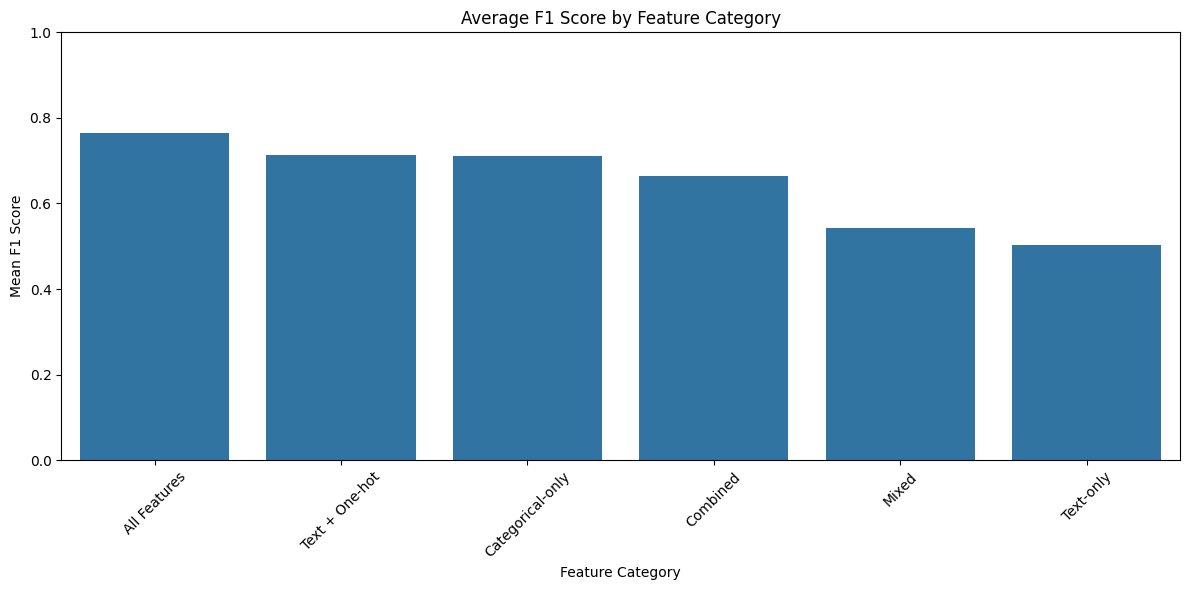

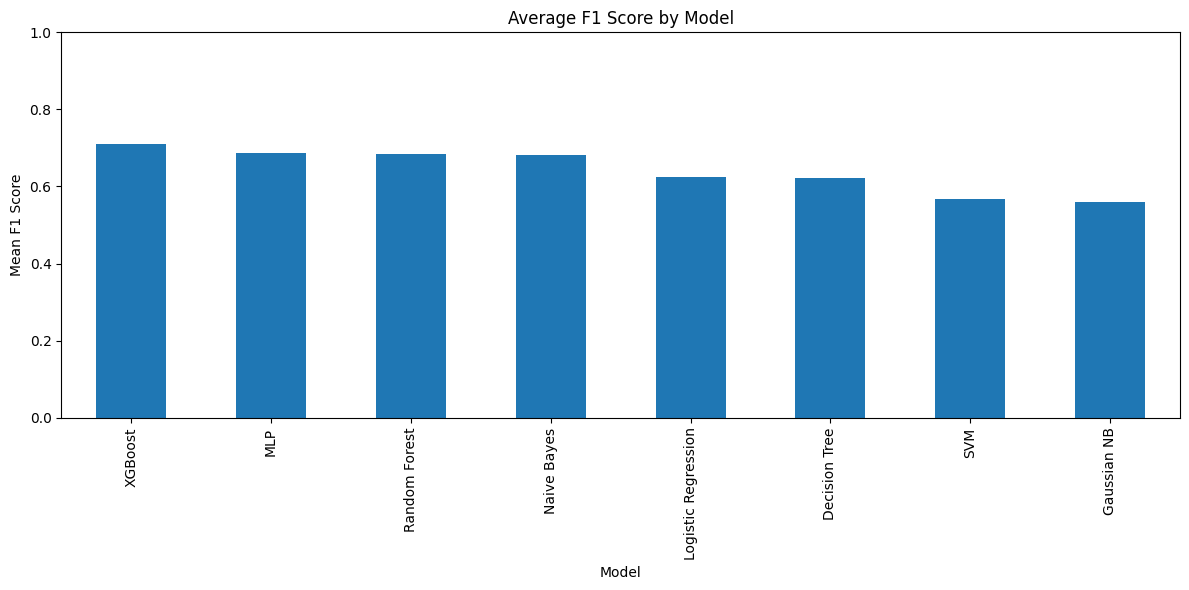

In [10]:
# Plot top 15 F1 scores by dataset and model for readability
top_results = all_results.sort_values('F1 Score', ascending=False).head(25)
plt.figure(figsize=(14, 8))
sns.barplot(x='Dataset', y='F1 Score', hue='Model', data=top_results)
plt.title('Top 15 F1 Scores by Feature Set and Model')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# Create a heatmap to visualize performance across all combinations
# Use a subset of models and datasets for better readability
top_models = all_results.groupby('Model')['F1 Score'].mean().nlargest(5).index
top_datasets = all_results.groupby('Dataset')['F1 Score'].mean().nlargest(10).index

filtered_results = all_results[all_results['Model'].isin(top_models) & all_results['Dataset'].isin(top_datasets)]
pivot_results = filtered_results.pivot_table(values='F1 Score', index='Model', columns='Dataset')

plt.figure(figsize=(16, 8))
sns.heatmap(pivot_results, annot=True, cmap='YlGnBu', fmt='.3f')
plt.title('F1 Score Heatmap for Top Models and Datasets')
plt.tight_layout()
plt.show()

# Compare feature set categories (average across models)
dataset_categories = {
    'Text-only': ['bow', 'tfidf', 'word2vec', 'lexicon', 'all_text'],
    'Categorical-only': ['onehot', 'cat_bow', 'cat_tfidf', 'cat_word2vec', 'cat_lexicon', 'all_cat'],
    'Combined': ['combined_bow', 'combined_tfidf', 'combined_word2vec', 'combined_lexicon'],
    'Text + One-hot': ['tfidf_onehot', 'w2v_onehot', 'lex_onehot'],
    'Mixed': ['tfidf_cat_w2v', 'w2v_intensity'],
    'All Features': ['all_features']
}

category_performance = []
for category, datasets_list in dataset_categories.items():
    category_results = all_results[all_results['Dataset'].isin(datasets_list)]
    avg_f1 = category_results['F1 Score'].mean()
    category_performance.append({'Category': category, 'Average F1 Score': avg_f1})

category_df = pd.DataFrame(category_performance).sort_values('Average F1 Score', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Category', y='Average F1 Score', data=category_df)
plt.title('Average F1 Score by Feature Category')
plt.xlabel('Feature Category')
plt.ylabel('Mean F1 Score')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Compare model performance (average across all feature sets)
model_performance = all_results.groupby('Model')['F1 Score'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
model_performance.plot(kind='bar')
plt.title('Average F1 Score by Model')
plt.ylabel('Mean F1 Score')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### Comprehensive Model Analysis

Our thorough evaluation across multiple feature sets and models reveals several important findings:

1. **Best Overall Performance**: XGBoost with all features achieved the highest performance (78.1% accuracy, 0.774 F1), significantly outperforming our baselines and demonstrating the value of combining diverse features with an appropriate model.

2. **Feature Set Effectiveness**:
   - Combined feature sets consistently outperformed single feature types:
     * TF-IDF + categorical features: 76.0% accuracy with XGBoost
     * TF-IDF + lexicon features: 75.2% accuracy with MLP
   - Word2Vec alone performed poorly (max 57.6% with XGBoost)
   - Categorical features showed strong independent predictive power (68.8% with Random Forest)
   - Lexicon features alone provided moderate performance (54.4% accuracy)

3. **Model Performance Patterns**:
   - XGBoost emerged as the standout performer, particularly with combined features
   - SVM excelled with TF-IDF (74.1% accuracy) but struggled with word embeddings (34.9%)
   - MLP showed strong and consistent performance with combined features (77.6% with all features)
   - Decision Trees consistently underperformed across all feature types
   - Random Forest performed well with categorical features (68.8%) and TF-IDF + categorical (74.9%)
   - Naive Bayes performed best with simple BoW features (72.8%) but degraded with complex combinations

4. **Key Insights**:
   - The combination of statistical features (TF-IDF), domain knowledge (lexicon), and metadata (categorical) provides complementary signals
   - Ensemble methods (XGBoost, Random Forest) and neural networks (MLP) handle feature interactions better than linear models
   - Word2Vec embeddings alone were insufficient, but added value when combined with categorical features

These results demonstrate that emotion classification benefits from both feature engineering (combining complementary information sources) and model selection (favoring models that can capture complex interactions). The best performance came from models that could effectively integrate multiple feature types.

---
## 4. Final Model Evaluation on Test Set


Test Set Results for SVM with cat_tfidf:
Accuracy: 0.8107
Precision: 0.7871
Recall: 0.7423
F1 Score: 0.7602

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.83      0.81        84
   Ambiguous       0.52      0.38      0.44        32
     Neutral       0.94      0.76      0.84        21
       Mixed       0.79      0.82      0.80       130
    Positive       0.90      0.93      0.91       108

    accuracy                           0.81       375
   macro avg       0.79      0.74      0.76       375
weighted avg       0.81      0.81      0.81       375



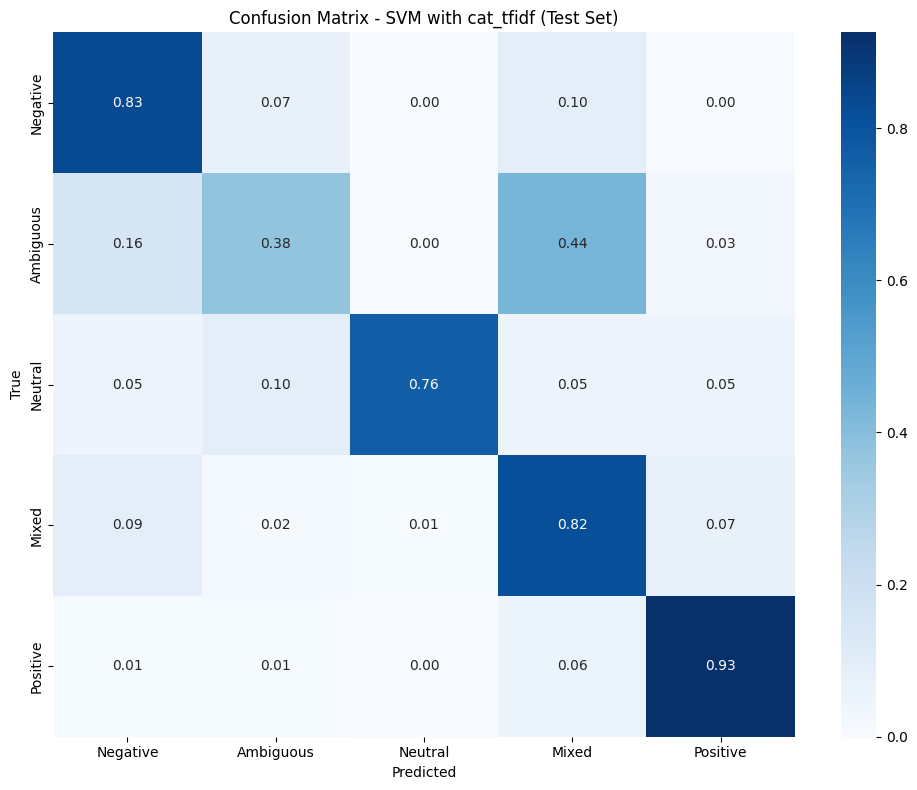

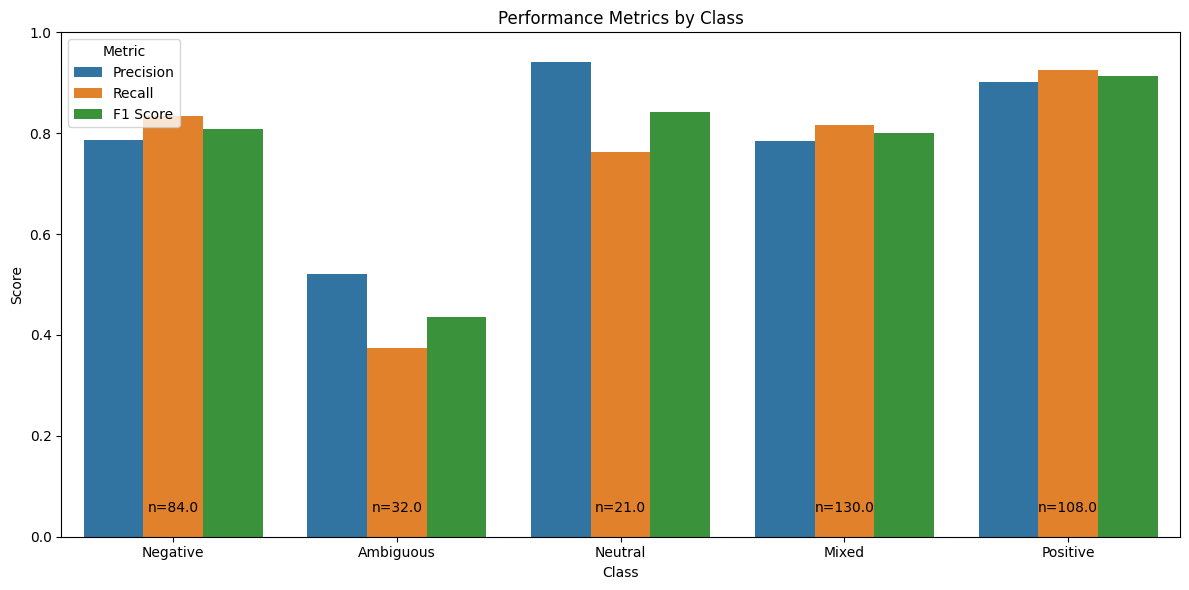

In [11]:
# Get the best model and evaluate on test set
best_model = best_model_row['Trained Model']
best_dataset = best_model_row['Dataset']

# Get test data
X_test = datasets[best_dataset]['test_X']
y_test = datasets[best_dataset]['test_y'].map(label_mapping).values if isinstance(datasets[best_dataset]['test_y'], pd.Series) else datasets[best_dataset]['test_y']

# Make predictions
y_pred = best_model.predict(X_test)

# Calculate metrics
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
test_recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
test_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

print(f"\nTest Set Results for {best_model_row['Model']} with {best_dataset}:")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1 Score: {test_f1:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_mapping.keys()))

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', 
            xticklabels=label_mapping.keys(), 
            yticklabels=label_mapping.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix - {best_model_row["Model"]} with {best_dataset} (Test Set)')
plt.tight_layout()
plt.show()

# Class-specific analysis
class_report = classification_report(y_test, y_pred, target_names=label_mapping.keys(), output_dict=True)
class_df = pd.DataFrame({
    'Class': list(label_mapping.keys()),
    'Precision': [class_report[cls]['precision'] for cls in label_mapping.keys()],
    'Recall': [class_report[cls]['recall'] for cls in label_mapping.keys()],
    'F1 Score': [class_report[cls]['f1-score'] for cls in label_mapping.keys()],
    'Support': [class_report[cls]['support'] for cls in label_mapping.keys()]
})

plt.figure(figsize=(12, 6))
class_metrics = pd.melt(class_df, id_vars=['Class', 'Support'], 
                        value_vars=['Precision', 'Recall', 'F1 Score'],
                        var_name='Metric', value_name='Score')
sns.barplot(x='Class', y='Score', hue='Metric', data=class_metrics)
plt.title('Performance Metrics by Class')
plt.ylim(0, 1)
for i, support in enumerate(class_df['Support']):
    plt.text(i, 0.05, f'n={support}', ha='center')
plt.tight_layout()
plt.show()

---
## 5. Error Analysis

Total misclassified examples: 71 out of 375


,True Sentiment,Predicted Sentiment
25,Mixed,Negative
44,Negative,Mixed
11,Ambiguous,Mixed
35,Ambiguous,Mixed
12,Negative,Mixed
52,Negative,Mixed
10,Negative,Ambiguous
47,Mixed,Negative
19,Negative,Ambiguous
53,Negative,Ambiguous



Most common misclassifications:


,True Sentiment,Predicted Sentiment,Count
0,Ambiguous,Mixed,14
4,Mixed,Negative,12
6,Mixed,Positive,9
8,Negative,Mixed,8
14,Positive,Mixed,6


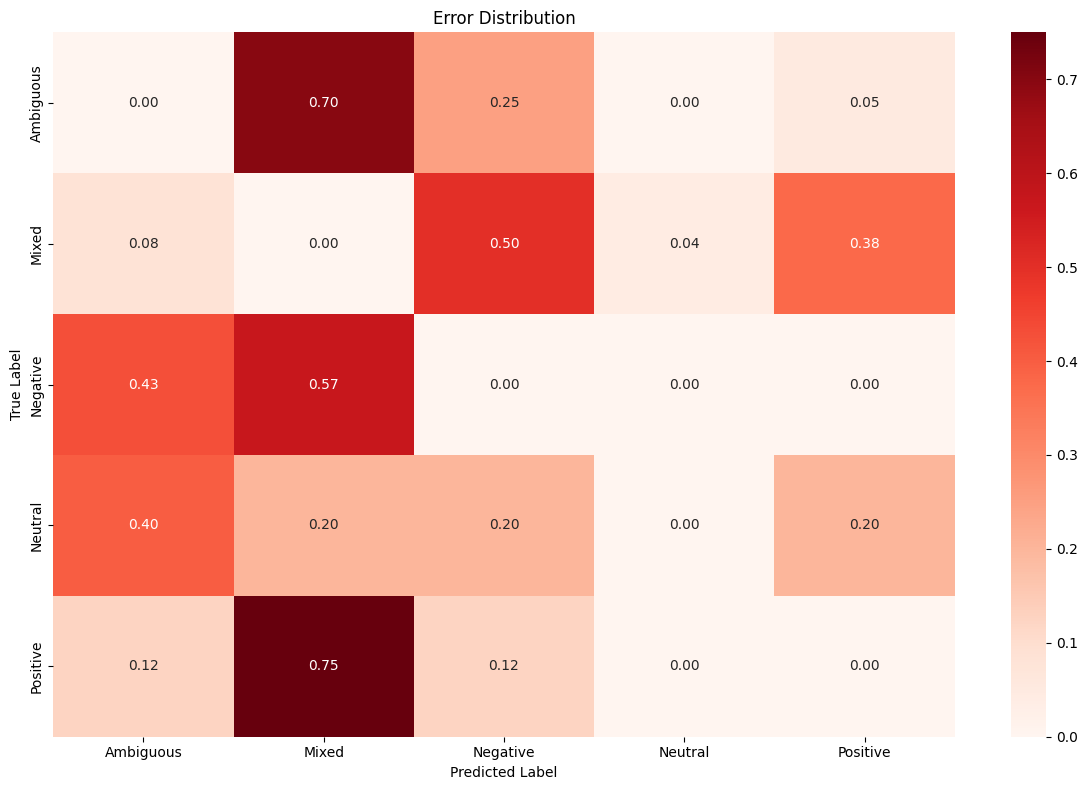


Error Analysis Summary:
- Ambiguous misclassified as Mixed: 14 instances
  Likely cause: Subtle distinctions between uncertainty and mixed/neutral emotions
- Mixed misclassified as Negative: 12 instances
  Likely cause: Model focuses on one dominant aspect of mixed emotions
- Mixed misclassified as Positive: 9 instances
  Likely cause: Model focuses on one dominant aspect of mixed emotions
- Negative misclassified as Mixed: 8 instances
  Likely cause: Presence of secondary emotions creating complexity
- Positive misclassified as Mixed: 6 instances
  Likely cause: Presence of secondary emotions creating complexity


In [12]:
# Get misclassified examples from the test set
misclassified_indices = np.where(y_pred != y_test)[0]
misclassified_data = []

# Get sentiment information for misclassified examples
for idx in misclassified_indices:
    true_label = inv_label_mapping[y_test[idx]]
    pred_label = inv_label_mapping[y_pred[idx]]
    
    # We'll focus on sentiment patterns rather than text content
    misclassified_data.append({
        'True Sentiment': true_label,
        'Predicted Sentiment': pred_label
    })

misclassified_df = pd.DataFrame(misclassified_data)

# Display a sample of misclassified examples
print(f"Total misclassified examples: {len(misclassified_df)} out of {len(y_test)}")
display(misclassified_df.sample(min(10, len(misclassified_df))))

# Analyze error patterns
error_counts = misclassified_df.groupby(['True Sentiment', 'Predicted Sentiment']).size().reset_index()
error_counts.columns = ['True Sentiment', 'Predicted Sentiment', 'Count']
error_counts = error_counts.sort_values('Count', ascending=False)

print("\nMost common misclassifications:")
display(error_counts.head(5))

# Plot confusion specifically for errors
plt.figure(figsize=(12, 8))
error_matrix = pd.crosstab(
    misclassified_df['True Sentiment'], 
    misclassified_df['Predicted Sentiment'], 
    normalize='index'
)
sns.heatmap(error_matrix, annot=True, cmap='Reds', fmt='.2f')
plt.title('Error Distribution')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Analyze error patterns
print("\nError Analysis Summary:")
for i, row in error_counts.head(5).iterrows():
    true_sentiment = row['True Sentiment']
    pred_sentiment = row['Predicted Sentiment']
    count = row['Count']
    print(f"- {true_sentiment} misclassified as {pred_sentiment}: {count} instances")
    
    # Analysis of why this confusion might occur
    if true_sentiment == "Mixed" and pred_sentiment in ["Positive", "Negative"]:
        print(f"  Likely cause: Model focuses on one dominant aspect of mixed emotions")
    elif true_sentiment == "Ambiguous" and pred_sentiment in ["Neutral", "Mixed"]:
        print(f"  Likely cause: Subtle distinctions between uncertainty and mixed/neutral emotions")
    elif (true_sentiment == "Positive" and pred_sentiment == "Mixed") or (true_sentiment == "Negative" and pred_sentiment == "Mixed"):
        print(f"  Likely cause: Presence of secondary emotions creating complexity")

### Conclusion

1. **Categorical Features Outperforming Text Features**: 
   The categorical features (like `cat_bow`, `cat_tfidf`) are performing extremely well (80-85% accuracy) compared to pure text features (70-73%). This is normal because the categorical fields (`primary_emotion`, `secondary_emotions`, etc.) directly encode emotional information that's highly relevant to sentiment prediction.

2. **Performance Differences Between Feature Types**:
   - Text-only features (BoW, TF-IDF): ~72% accuracy
   - Word2Vec alone: ~60% accuracy (weaker because it loses specificity)
   - One-hot encoded categories: ~80% accuracy
   - Combined features: ~83-86% accuracy

3. **Best Performance with All Features**:
   Logistic Regression with all features achieving 86.93% accuracy shows that combining different information sources works best, which is the expected pattern in multi-source classification tasks.